In [46]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,f1_score
from sklearn.pipeline import Pipeline
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings;warnings.filterwarnings('ignore')

In [2]:
glass=pd.read_csv('Glass.csv')
y=glass['Type']
X=glass.drop('Type',axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [3]:
lda=LinearDiscriminantAnalysis()
lda.fit(X_train,y_train)
y_pred=lda.predict(X_test)
print(classification_report(y_test,y_pred))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.55      0.76      0.64        21
building_windows_non_float_processed       0.65      0.57      0.60        23
                          containers       0.50      0.50      0.50         4
                           headlamps       1.00      0.67      0.80         9
                           tableware       0.75      1.00      0.86         3
     vehicle_windows_float_processed       0.50      0.20      0.29         5

                            accuracy                           0.63        65
                           macro avg       0.66      0.62      0.61        65
                        weighted avg       0.65      0.63      0.62        65



In [4]:
qda=QuadraticDiscriminantAnalysis()
qda.fit(X_train,y_train)
y_pred=qda.predict(X_test)
print(classification_report(y_test,y_pred))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.47      0.76      0.58        21
building_windows_non_float_processed       0.44      0.35      0.39        23
                          containers       0.00      0.00      0.00         4
                           headlamps       0.62      0.89      0.73         9
                           tableware       0.00      0.00      0.00         3
     vehicle_windows_float_processed       0.00      0.00      0.00         5

                            accuracy                           0.49        65
                           macro avg       0.26      0.33      0.28        65
                        weighted avg       0.39      0.49      0.43        65



In [12]:
vehicle=pd.read_csv('Vehicle.csv')
y=vehicle['Class']
X=vehicle.drop('Class',axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [6]:
lda=LinearDiscriminantAnalysis()
lda.fit(X_train,y_train)
y_pred=lda.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         bus       0.93      0.95      0.94        65
        opel       0.68      0.67      0.68        64
        saab       0.69      0.69      0.69        65
         van       0.95      0.93      0.94        60

    accuracy                           0.81       254
   macro avg       0.81      0.81      0.81       254
weighted avg       0.81      0.81      0.81       254



In [13]:
qda=QuadraticDiscriminantAnalysis()
qda.fit(X_train,y_train)
y_pred=qda.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         bus       0.98      0.92      0.95        65
        opel       0.75      0.77      0.76        64
        saab       0.77      0.75      0.76        65
         van       0.92      0.98      0.95        60

    accuracy                           0.85       254
   macro avg       0.86      0.86      0.86       254
weighted avg       0.86      0.85      0.85       254



In [28]:
iris=pd.read_csv('Iris.csv')
y=iris['Species']
X=iris.drop('Species',axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [25]:
lda=LinearDiscriminantAnalysis()
lda.fit(X_train,y_train)
y_pred=lda.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.93      0.93        15
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [26]:
qda=QuadraticDiscriminantAnalysis()
qda.fit(X_train,y_train)
y_pred=qda.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## LDA Transformation

<Axes: xlabel='lineardiscriminantanalysis0', ylabel='lineardiscriminantanalysis1'>

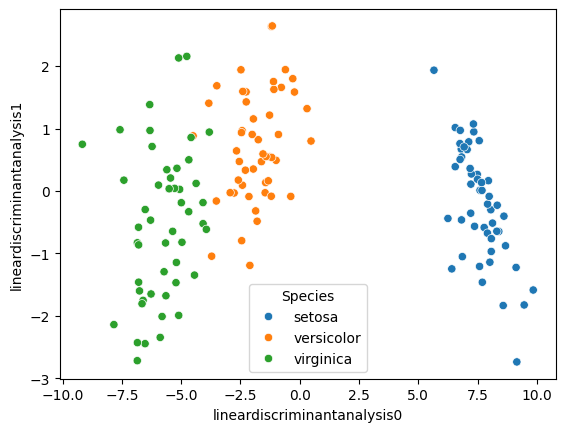

In [30]:
lda=LinearDiscriminantAnalysis().set_output(transform='pandas')
X_lda=lda.fit_transform(X,y)
X_lda['Species']=iris['Species']
sns.scatterplot(data=X_lda,x='lineardiscriminantanalysis0',y='lineardiscriminantanalysis1',hue='Species')

In [32]:
glass=pd.read_csv('Glass.csv')
y=glass['Type']
X=glass.drop('Type',axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [34]:
lda = LinearDiscriminantAnalysis().set_output(transform='pandas')
X_trn_lda = lda.fit_transform(X_train,y_train)
X_tst_lda = lda.transform(X_test)

In [37]:
lr = LogisticRegression()
lr.fit(X_trn_lda,y_train)
y_pred = lr.predict(X_tst_lda)
print(classification_report(y_test,y_pred))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.58      0.71      0.64        21
building_windows_non_float_processed       0.67      0.61      0.64        23
                          containers       0.50      0.50      0.50         4
                           headlamps       1.00      0.89      0.94         9
                           tableware       1.00      0.67      0.80         3
     vehicle_windows_float_processed       0.25      0.20      0.22         5

                            accuracy                           0.65        65
                           macro avg       0.67      0.60      0.62        65
                        weighted avg       0.66      0.65      0.65        65



In [39]:
svm = SVC(kernel='linear', C=1)
svm.fit(X_trn_lda,y_train)
y_pred = svm.predict(X_tst_lda)
print(classification_report(y_test,y_pred))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.57      0.76      0.65        21
building_windows_non_float_processed       0.59      0.57      0.58        23
                          containers       0.50      0.50      0.50         4
                           headlamps       0.86      0.67      0.75         9
                           tableware       1.00      0.67      0.80         3
     vehicle_windows_float_processed       0.00      0.00      0.00         5

                            accuracy                           0.60        65
                           macro avg       0.59      0.53      0.55        65
                        weighted avg       0.59      0.60      0.59        65



In [43]:
lr = LogisticRegression()
lda = LinearDiscriminantAnalysis().set_output(transform='pandas')
pipe = Pipeline([("LDA", lda),("LR", lr)])
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test,y_pred))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.58      0.71      0.64        21
building_windows_non_float_processed       0.67      0.61      0.64        23
                          containers       0.50      0.50      0.50         4
                           headlamps       1.00      0.89      0.94         9
                           tableware       1.00      0.67      0.80         3
     vehicle_windows_float_processed       0.25      0.20      0.22         5

                            accuracy                           0.65        65
                           macro avg       0.67      0.60      0.62        65
                        weighted avg       0.66      0.65      0.65        65



In [44]:
svm = SVC(kernel='linear', C=1)
lda = LinearDiscriminantAnalysis().set_output(transform='pandas')
pipe = Pipeline([("LDA", lda),("SVM", svm)])
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test,y_pred))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.57      0.76      0.65        21
building_windows_non_float_processed       0.59      0.57      0.58        23
                          containers       0.50      0.50      0.50         4
                           headlamps       0.86      0.67      0.75         9
                           tableware       1.00      0.67      0.80         3
     vehicle_windows_float_processed       0.00      0.00      0.00         5

                            accuracy                           0.60        65
                           macro avg       0.59      0.53      0.55        65
                        weighted avg       0.59      0.60      0.59        65

